In [1]:
import numpy as np
import matplotlib.pyplot as plt
import datasets
from privacy_estimates.experiments.aml import JobList
from sklearn.metrics import roc_curve, roc_auc_score, auc
import re
import os

/anaconda/envs/privacy-estimates/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def compute_performance(scores_members, scores_non_members):
    mia_performance = {}
    
    member_vals = [val for val in scores_members]
    non_member_vals = [val for val in scores_non_members]
    mia_performance['auc'] = roc_auc_score([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    fpr, tpr, thresholds = roc_curve([1]*len(member_vals) + [0]*len(non_member_vals), member_vals + non_member_vals)
    for target_fpr in (0.01, 0.05, 0.1):
        mia_performance[f'tpr_at_{target_fpr}'] = np.interp(target_fpr, fpr, tpr)
    print(f"AUC: {mia_performance['auc']}, TPR@0.01: {mia_performance['tpr_at_0.01']}, TPR@0.05: {mia_performance['tpr_at_0.05']}, TPR@0.1: {mia_performance['tpr_at_0.1']}")

    # also add the curves
    mia_performance['fpr'] = fpr
    mia_performance['tpr'] = tpr

    return mia_performance

# let's also make a function that computes the performance directly from the url

from datetime import datetime

def compute_performance_from_url(url, job_name = None):
    jobs = JobList.from_urls([url])
    if job_name is None:
        job_name = str(datetime.now())
    
    if not os.path.exists(f'./mia_results/{job_name}'):
        test = jobs[0].get_node('estimate_privacy').download_input('scores', f'./mia_results/{job_name}/scores')
        test = jobs[0].get_node('estimate_privacy').download_input('challenge_bits', f'./mia_results/{job_name}/challenge_bits')
    scores = datasets.load_from_disk(f'./mia_results/{job_name}/scores')
    bits = datasets.load_from_disk(f'./mia_results/{job_name}/challenge_bits')
    
    membership_scores = np.array([k['score'] for k in scores])
    membership_labels = np.array([k['challenge_bit'] for k in bits])
    members = membership_scores[membership_labels == 1]
    non_members = membership_scores[membership_labels == 0]
    return compute_performance(members, non_members)

In [3]:
def extract_aml_urls(log_file_path):
    # Initialize a list to store the extracted URLs
    aml_urls = []

    # Define a regular expression to match the log entries containing AML URLs
    aml_url_pattern = re.compile(r'AML URL: (https://ml\.azure\.com/runs/[\w\-\?&=/]+)')

    # Open and read the log file
    with open(log_file_path, 'r') as file:
        for line in file:
            match = aml_url_pattern.search(line)
            if match:
                aml_urls.append(match.group(1))

    return aml_urls

In [5]:
extract_aml_urls('../synthetic_ppl_agnews_final_launch.txt')

['https://ml.azure.com/runs/serene_crayon_qkgkmsx782?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/ashy_knee_1pxmw4c3wf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/loving_bottle_ys6qmynzkw?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/upbeat_eagle_w9wh27mk25?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/strong_reggae_b6mkgkrtw0?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-

In [6]:
# first the non synthetic results

perplexities = [10, 10**1.5, 10**2, 10**2.5, 10**3, 10**3.5, 10**4, 10**4.5, 10**5]

# we recycle two of the urls from previous experiments
no_synthetic_urls = ['https://ml.azure.com/runs/crimson_street_3wtxkmjtj5?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/musing_sail_wmjq1sh67n?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/nifty_brush_m79xdknbbm?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/goofy_foot_rs86w6b5rp?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/silly_wolf_1pwzrw5zl1?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/silver_rabbit_vdf9vrby6b?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/joyful_pen_1zjx6wwwgs?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/amusing_music_ms4rgwx19z?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/keen_energy_w8hmyn721f?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47']

synthetic_urls = ['https://ml.azure.com/runs/serene_crayon_qkgkmsx782?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/ashy_knee_1pxmw4c3wf?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/loving_bottle_ys6qmynzkw?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/upbeat_eagle_w9wh27mk25?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/eager_nose_lcxm2pbn34?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/strong_reggae_b6mkgkrtw0?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/orange_milk_9wnz380ggr?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/willing_candle_2h1b0yj6pv?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47',
 'https://ml.azure.com/runs/lucid_lizard_gq68gf94s4?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47']

assert len(no_synthetic_urls) == len(perplexities)
assert len(synthetic_urls) == len(perplexities)


In [7]:
non_synthetic_results = dict()
synthetic_results = dict()

for i in range(len(perplexities)):
    print(f"Perplexity: {perplexities[i]}")
    print("Non synthetic")
    try:
        performance = compute_performance_from_url(no_synthetic_urls[i])
        non_synthetic_results[perplexities[i]] = performance
        print('---')
    except Exception as e:
        print(e)
        non_synthetic_results[perplexities[i]] ={'auc': None, 'tpr_at_0.01': None, 'tpr_at_0.05': None, 'tpr_at_0.1': None}
        print('---')
    
    print('Synthetic')
    try:
        performance = compute_performance_from_url(synthetic_urls[i])
        synthetic_results[perplexities[i]] = performance
        print('---')
    except Exception as e:
        print(e)
        synthetic_results[perplexities[i]] ={'auc': None, 'tpr_at_0.01': None, 'tpr_at_0.05': None, 'tpr_at_0.1': None}
        print('---')

Perplexity: 10
Non synthetic
AUC: 0.792187268704666, TPR@0.01: 0.252465483234714, TPR@0.05: 0.398422090729783, TPR@0.1: 0.514792899408284
---
Synthetic
AUC: 0.7200251249244852, TPR@0.01: 0.1341222879684418, TPR@0.05: 0.2879684418145957, TPR@0.1: 0.378698224852071
---
Perplexity: 31.622776601683793
Non synthetic
AUC: 0.9219246972406592, TPR@0.01: 0.5502958579881657, TPR@0.05: 0.6725838264299803, TPR@0.1: 0.7988165680473372
---
Synthetic
AUC: 0.67797688346916, TPR@0.01: 0.06903353057199212, TPR@0.05: 0.1932938856015779, TPR@0.1: 0.27613412228796846
---
Perplexity: 100
Non synthetic
AUC: 0.9226928477981686, TPR@0.01: 0.3806706114398422, TPR@0.05: 0.727810650887574, TPR@0.1: 0.796844181459566
---
Synthetic
AUC: 0.7330276734239911, TPR@0.01: 0.10650887573964497, TPR@0.05: 0.2406311637080868, TPR@0.1: 0.3609467455621302
---
Perplexity: 316.22776601683796
Non synthetic
AUC: 0.9087861220799276, TPR@0.01: 0.39644970414201186, TPR@0.05: 0.6232741617357002, TPR@0.1: 0.777120315581854
---
Syntheti

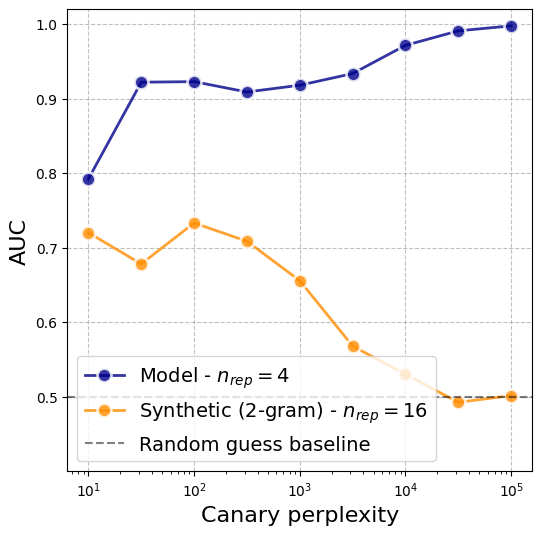

In [8]:
plt.figure(figsize=(6,6))
plt.plot(perplexities, [non_synthetic_results[p]['auc'] for p in perplexities], '-o', alpha=0.8, 
             color ='darkblue', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Model - $n_{rep}=4$')
plt.plot(perplexities, [synthetic_results[p]['auc'] for p in perplexities], '-o', alpha=0.8, 
             color ='darkorange', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Synthetic (2-gram) - $n_{rep}=16$')

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label = 'Random guess baseline')


plt.xticks([10**k for k in (0, 1, 2, 3, 4, 5)])
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], labels=['0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

# Enable the grid
plt.grid(True, which="major", ls="--", alpha=0.8)

plt.legend(loc='lower left', fontsize=14)
plt.xlabel('Canary perplexity', fontsize=16)
plt.ylabel('AUC', fontsize=16)
plt.ylim(0.4, 1.02)
plt.xscale('log')
plt.savefig('figures/ppl_experiment_agnews.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()

If we do want to add results for in-canary results, we need to run the notebook `notebooks/compute_perplexity_canaries.ipynb` (on GPU instance). 

Then we can load: 

In [9]:
import pickle 

with open('ppl_in_canaries_boxplot_agnews', 'rb') as f:
    ppl_in_canaries = pickle.load(f)

In [11]:
# also get the performance

in_canary_no_synthetic_url =  "https://ml.azure.com/runs/jovial_crowd_tqywfhsgfj?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourceGroups/ppml/providers/Microsoft.MachineLearningServices/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47#"
performance = compute_performance_from_url(in_canary_no_synthetic_url)
non_synthetic_results['in_canary'] = performance

in_canary_synthetic_url = "https://ml.azure.com/runs/icy_balloon_ww1kjz7gb5?wsid=/subscriptions/acc09744-1ee3-4242-b375-93421c63af0c/resourcegroups/PPML/workspaces/M365Research-PPML-EUS&tid=72f988bf-86f1-41af-91ab-2d7cd011db47"
performance = compute_performance_from_url(in_canary_synthetic_url)
synthetic_results['in_canary'] = performance

AUC: 0.9119747470504218, TPR@0.01: 0.5443786982248521, TPR@0.05: 0.6942800788954635, TPR@0.1: 0.7554240631163708
AUC: 0.6783489563954535, TPR@0.01: 0.03944773175542406, TPR@0.05: 0.1834319526627219, TPR@0.1: 0.2781065088757396


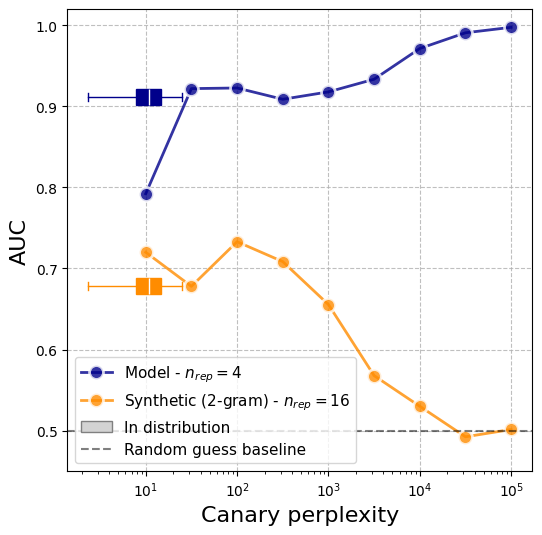

In [13]:
plt.figure(figsize=(6,6))
plt.plot(perplexities, [non_synthetic_results[p]['auc'] for p in perplexities], '-o', alpha=0.8, 
             color ='darkblue', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Model - $n_{rep}=4$')

plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[non_synthetic_results['in_canary']['auc']],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='darkblue', color='darkblue'),
    whiskerprops=dict(color='darkblue'),
    capprops=dict(color='darkblue'),
    flierprops=dict(marker='o', color='darkblue', alpha=0.0),
    medianprops=dict(color='white', linewidth=1)  # Change the median line color to red or black
)

plt.plot(perplexities,
        [synthetic_results[p]['auc'] for p in perplexities],
        '-o', alpha=0.8, color ='darkorange', markersize=10, linewidth=2, markeredgewidth=2, markeredgecolor='white', label=r'Synthetic (2-gram) - $n_{rep}=16$')

plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[synthetic_results['in_canary']['auc']],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='darkorange', color='darkorange'),
    whiskerprops=dict(color='darkorange'),
    capprops=dict(color='darkorange'),
    flierprops=dict(marker='o', color='darkorange', alpha=0.0),
    medianprops=dict(color='white', linewidth=1)  # Change the median line color to red or black
)

# just for the label
plt.boxplot(
    ppl_in_canaries,
    vert=False,
    positions=[2.0],
    widths=0.02,  # Adjust width to fit your plot
    patch_artist=True,
    boxprops=dict(facecolor='lightgrey', color='grey'),
    whiskerprops=dict(color='grey'),
    capprops=dict(color='grey'),
    flierprops=dict(marker='o', color='grey', alpha=0.5),
    medianprops=dict(color='white', linewidth=1), 
    label = 'In distribution'
)

plt.axhline(y=0.5, color='black', linestyle='--', alpha=0.5, label = 'Random guess baseline')

plt.xticks([10**k for k in (0, 1, 2, 3, 4, 5)])
plt.yticks([0.5, 0.6, 0.7, 0.8, 0.9, 1.0], labels=['0.5', '0.6', '0.7', '0.8', '0.9', '1.0'])

# Enable the grid
plt.grid(True, which="major", ls="--", alpha=0.8)

plt.legend(loc='lower left', fontsize=11)
plt.xlabel('Canary perplexity', fontsize=16)
plt.ylabel('AUC', fontsize=16)
plt.ylim(0.45, 1.02)
plt.xscale('log')
plt.savefig('figures/ppl_experiment_agnews_w_in_canaries.pdf', dpi=300, bbox_inches='tight', pad_inches=0)
plt.show()